# Plot Individual Traces
**Description:** This notebook visualizes the signals for a single embryo.  

* Dff trace
* Partial dff trace
* Spectrogram
* Hipass filter
* Lowpass filter

## Import Libraries

In [3]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import matplotlib as mpl
from scipy.signal import savgol_filter

from snazzy_analysis import Dataset, FrequencyAnalysis, myplots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

Specify the location of the data by editing `dataset_name`. Then specify the embryo, by picking an `emb_idx`.

In [4]:
dataset_name = "20240611"  # HERE
emb_idx = 0  # HERE

dataset_path = Path.cwd().parent.joinpath("data", dataset_name)
dataset = Dataset(dataset_path)

embryos = list(dataset.embryos)
emb = embryos[emb_idx]
trace = emb.trace

print(f"\n\nLoading {dataset_name} {emb.name}")

First peak detected before 30 mins. Skipping emb1..


Loading 20240611 emb2


## Configure Plot Style

Customize the Matplotlib plots with rcParams. For a full list of parameters see [matplotlib.rcParams](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#default-values-and-styling)

In [5]:
myplots.set_darkbg(False)

trace_rc = {
    "figure.figsize": (35, 6),
    "figure.frameon": False,
    "lines.linewidth": 3.5,
    "font.family": "Arial",
    "font.size": 40,
    "xtick.major.size": 10,  # length
    "xtick.major.width": 2,
    "ytick.major.size": 10,  # length
    "ytick.major.width": 2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelpad": 10,
    "axes.linewidth": 2.5,
}

partial_trace_rc = {
    "figure.figsize": (20, 8),
    "figure.frameon": False,
    "lines.linewidth": 4,
    "font.family": "Arial",
    "font.size": 40,
    "xtick.major.size": 10,  # length
    "xtick.major.width": 2,
    "ytick.major.size": 10,  # length
    "ytick.major.width": 2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelpad": 10,
    "axes.linewidth": 2.5,
}

spec_rc = {
    "figure.figsize": (35, 8),
    "figure.frameon": False,
    "font.family": "Arial",
    "font.size": 40,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 10,  # length
    "xtick.major.width": 2,
    "ytick.major.size": 10,  # length
    "ytick.major.width": 2,
    "axes.labelpad": 10,
    "axes.linewidth": 2.5,
}

mymap = mpl.colormaps["turbo"]
mymap.set_over("black")

## Plot DFF

Preprocesses the dff to a standardized length, then plots it over real time.

**preprocess_dff**

optional parameters:
* duration: target number of frames to include
* onset_pad: number of frames to include before onset


**plot_trace** 

optional parameters:
* color: line color
* xmin: x-axis minimum in minutes
* xmax: x-axis maximum in minutes
* xinterval: num of minutes between ticks
* ymin: y-axis minimum in minutes
* ymax: y-axis maximum in minutes
* yinterval: num of minutes between ticks

note: if you dont specify a color, one will be chosen for you

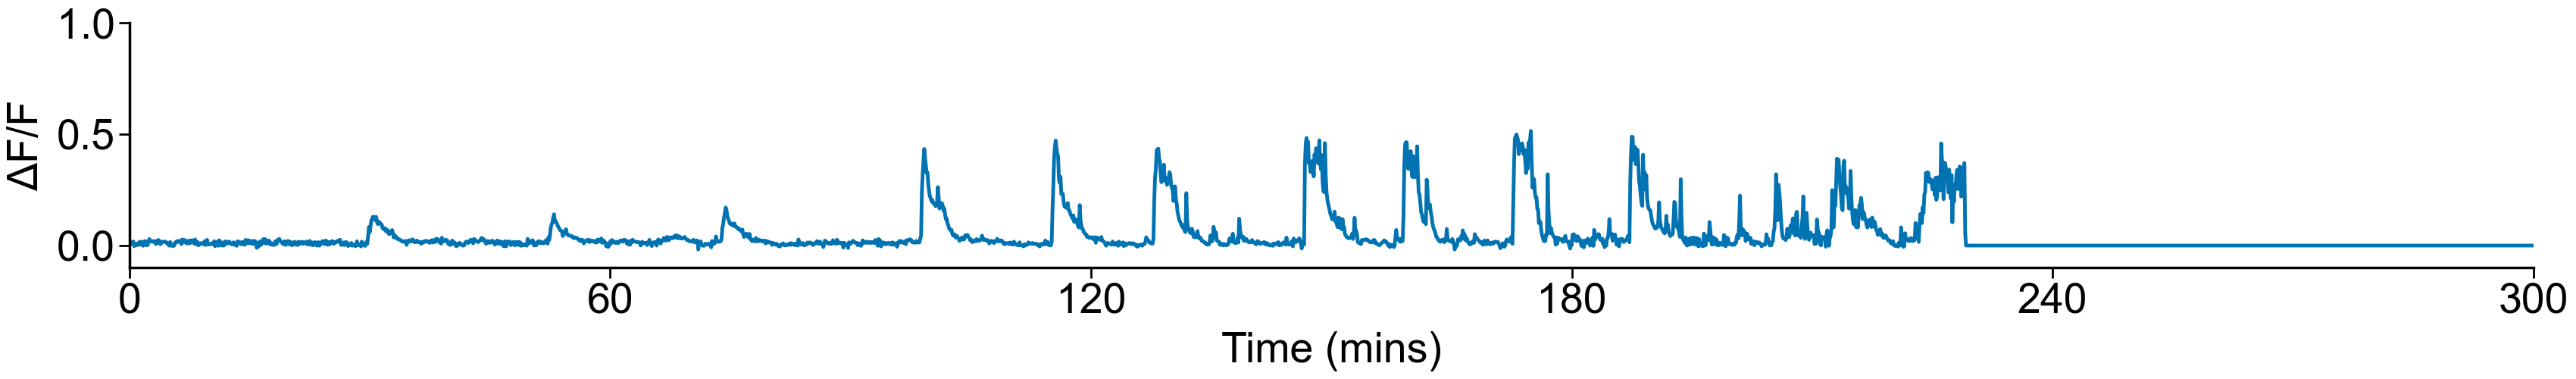

In [6]:
time, dff = trace.preprocess_dff()
myplots.plot_trace(
    time, dff, trace_rc, color="#0273b2ff", xmax=300, ymax=1, yinterval=0.5
)

## Plot Partial DFF

Preprocesses the dff to a standardized length, then plots it over real time.

**preprocess_dff** 

optional parameters:
* duration: target number of frames to include
* onset_pad: number of frames to include before onset


**plot_trace** 

optional parameters:
* color: line color
* xmin: x-axis minimum in minutes
* xmax: x-axis maximum in minutes
* xinterval: num of minutes between ticks
* ymin: y-axis minimum in minutes
* ymax: y-axis maximum in minutes
* yinterval: num of minutes between ticks

note: if you dont specify a color, one will be chosen for you

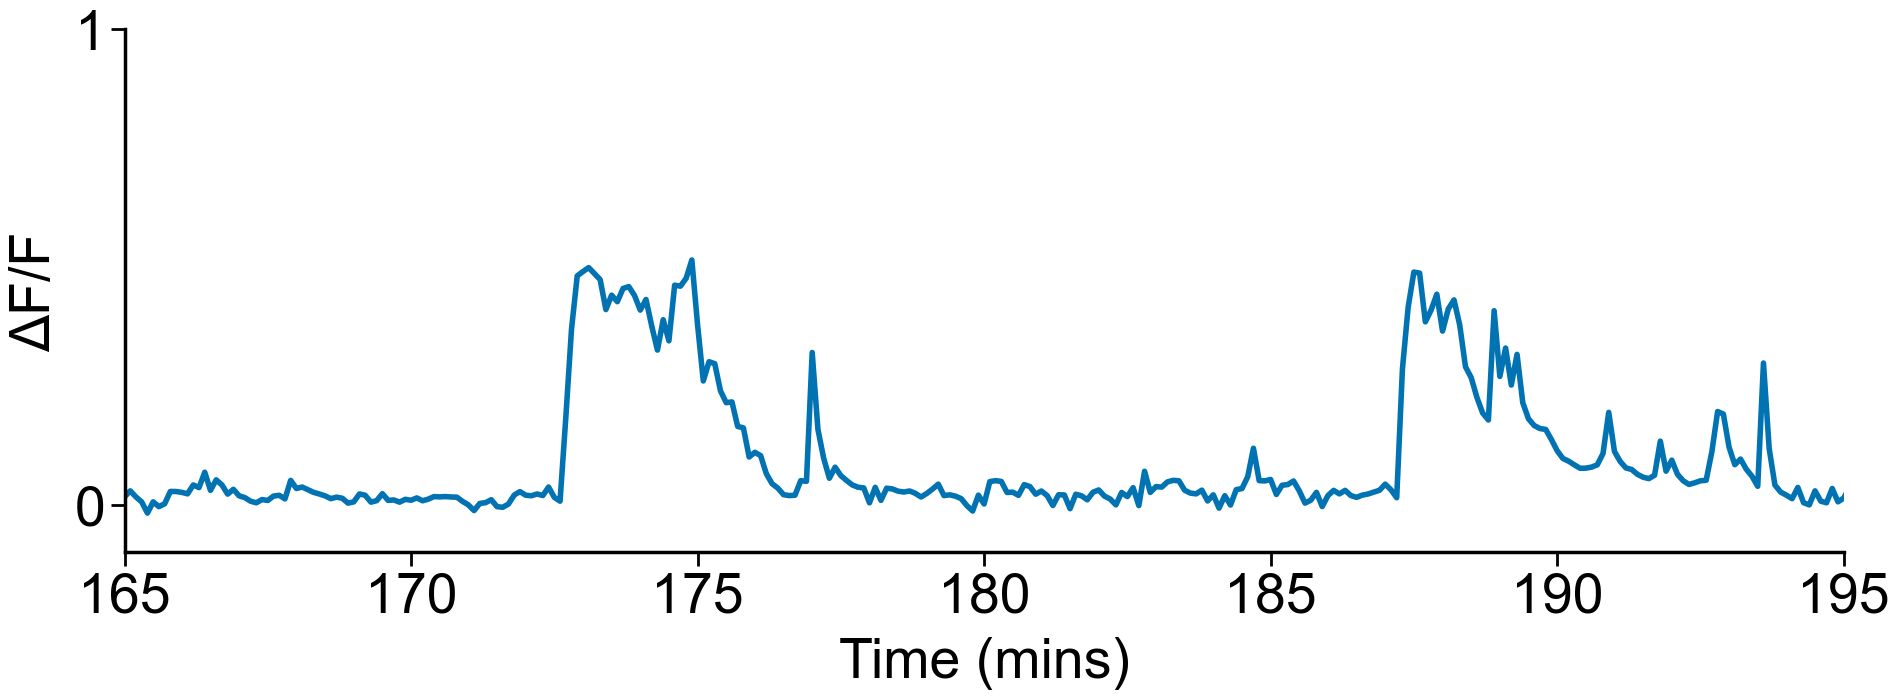

In [7]:
time, dff = trace.preprocess_dff()
myplots.plot_trace(
    time,
    dff,
    partial_trace_rc,
    color="#0273b2ff",
    xmin=165,
    xmax=195,
    xinterval=5,
    ymax=1,
)

## Plot Spectrogram

Preprocesses the dff to a standardized length, then plots the magnitude of its STFT over time. The x-axis displays time (columns), y-axis displays frequency (rows), and color displays intensity. 

**preprocess_dff** 

optional parameters:
* duration: target number of frames to include
* onset_pad: number of frames to include before onset


**calculate_STFT**

optional parameters:
* fs: sampling rate
* fft_size: num frames in each segment
* noverlap: num frames to overlap between segements

**plot_spec** 

optional parameters:
* display_colorbar: True to display, False to hide
* xmin: x-axis minimum in minutes
* xmax: x-axis maximum in minutes
* ymin: y-axis minimum in minutes
* ymax: y-axis maximum in minutes

emb2


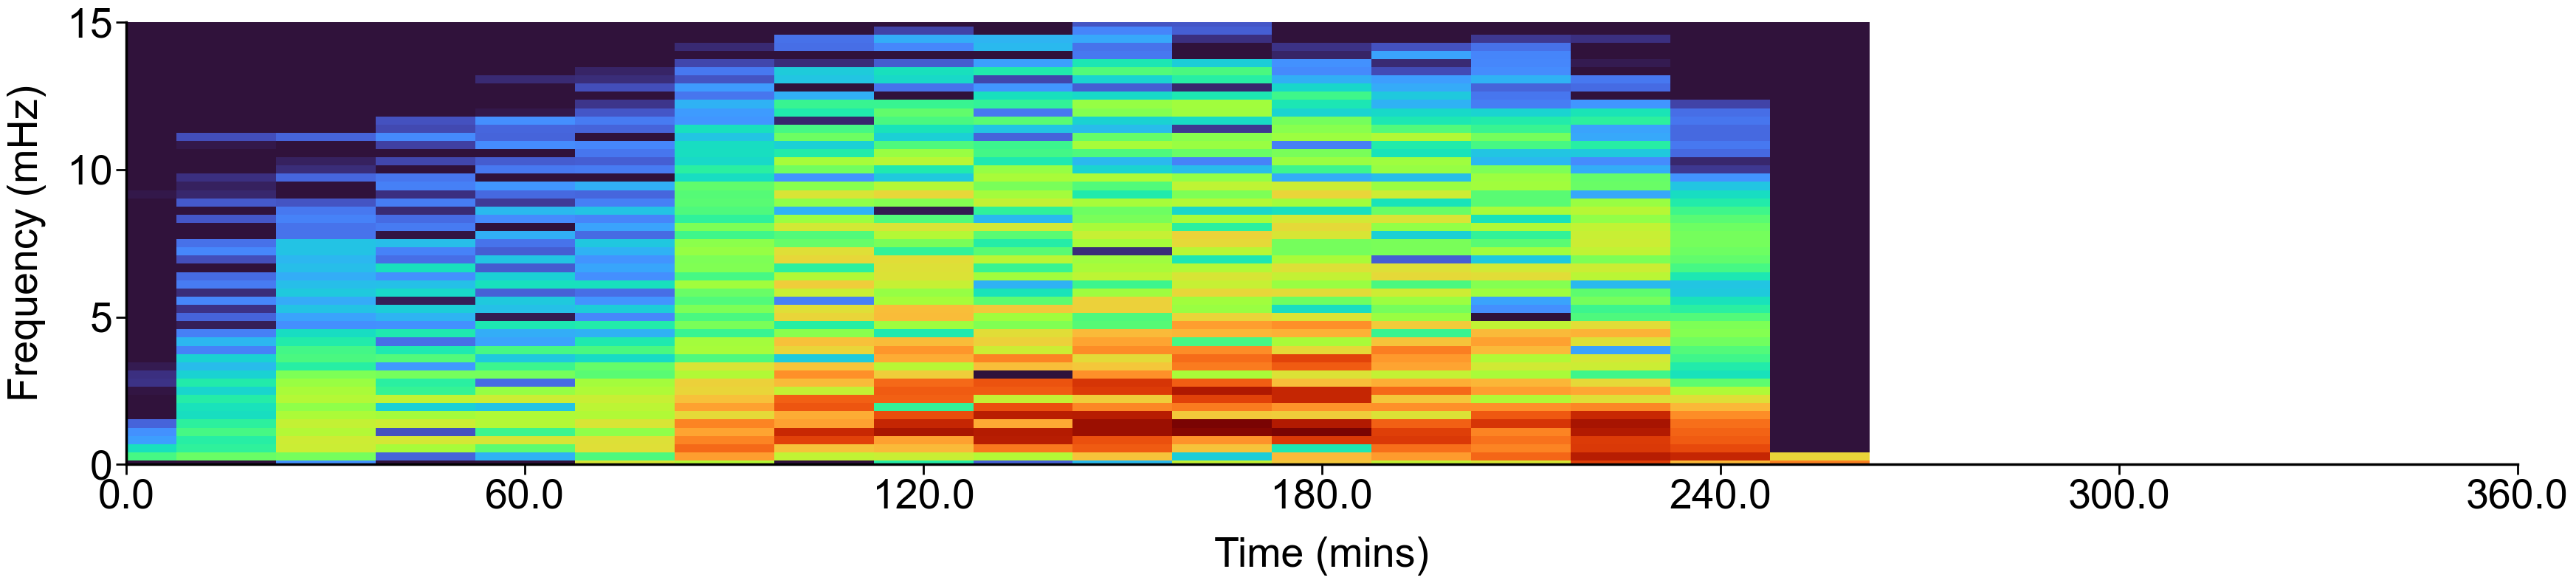

In [8]:
print(trace.name)
time, dff = trace.preprocess_dff()
smoothed_dff = savgol_filter(dff, window_length=25, polyorder=4)
f, t, Zxx = FrequencyAnalysis.calculate_STFT(smoothed_dff)
myplots.plot_spec(f, t, Zxx, mymap, spec_rc, display_colorbar=False, ymax=0.015)

## Apply Highpass Filter

**apply_hipass_filter**

optional parameters:

* fs: sampling rate
* fft_size: num frames in each segment
* numtaps: num of coefficients in the filter

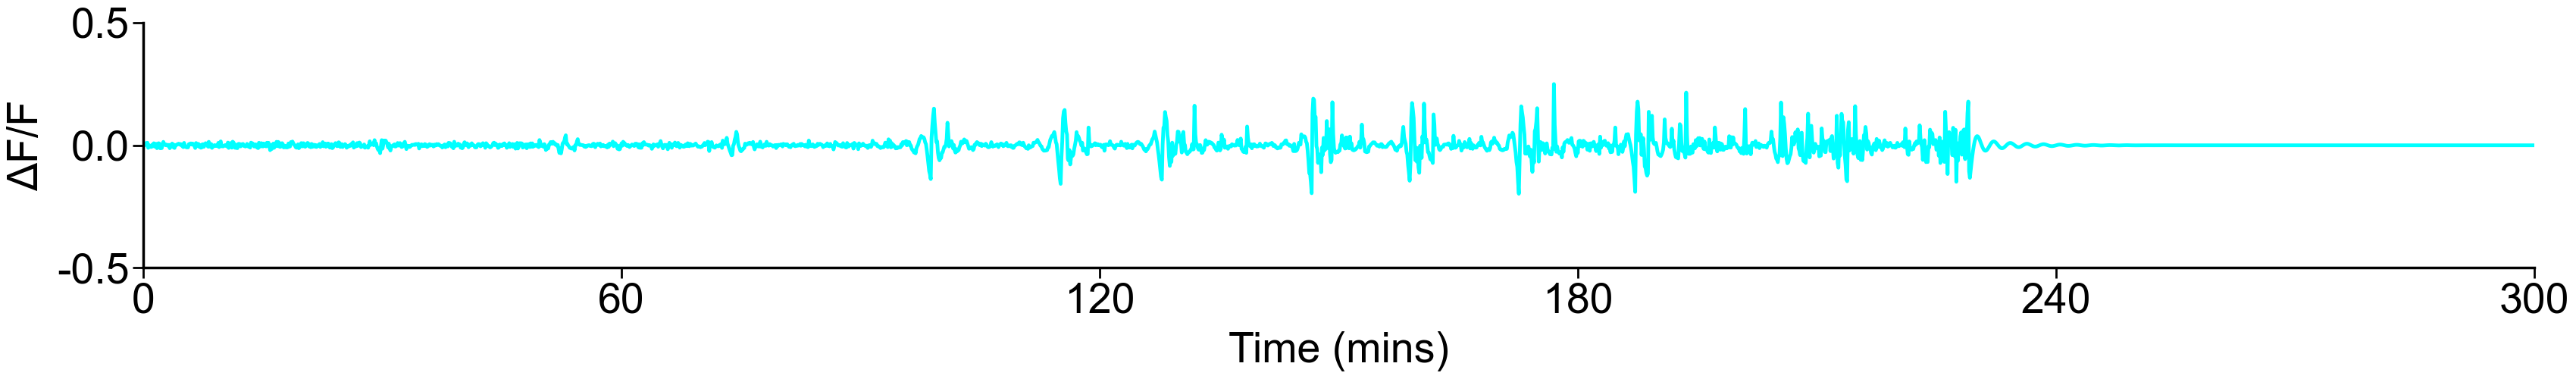

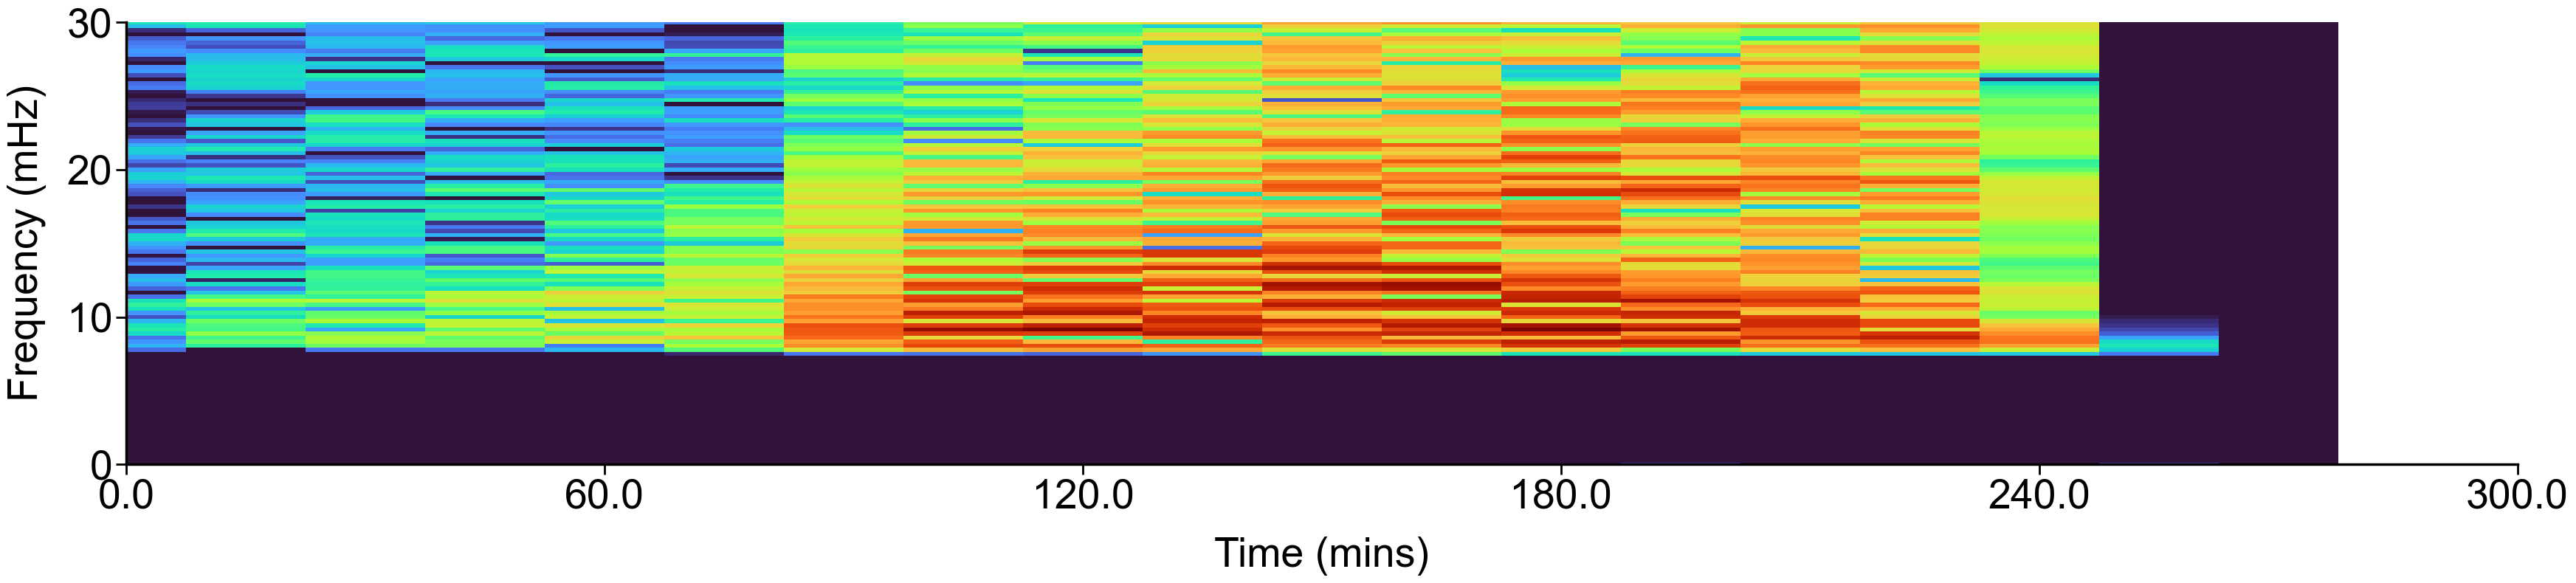

In [9]:
cutoff = 0.008  # frequency in Hz

f, t, Zxx = FrequencyAnalysis.calculate_STFT(dff)
hipass_dff = FrequencyAnalysis.apply_hipass_filter(dff, cutoff)

myplots.plot_trace(
    time,
    hipass_dff,
    trace_rc,
    color="cyan",
    xmax=300,
    ymin=-0.5,
    ymax=0.5,
    yinterval=0.5,
)

new_f, new_t, new_Zxx = FrequencyAnalysis.calculate_STFT(hipass_dff, fs=1 / 6)
myplots.plot_spec(
    new_f, new_t, new_Zxx, mymap, spec_rc, display_colorbar=False, xmax=300
)

## Apply Lowpass Filter

**apply_lopass_filter**

optional parameters:

* fs: sampling rate
* fft_size: num frames in each segment
* numtaps: num of coefficients in the filter

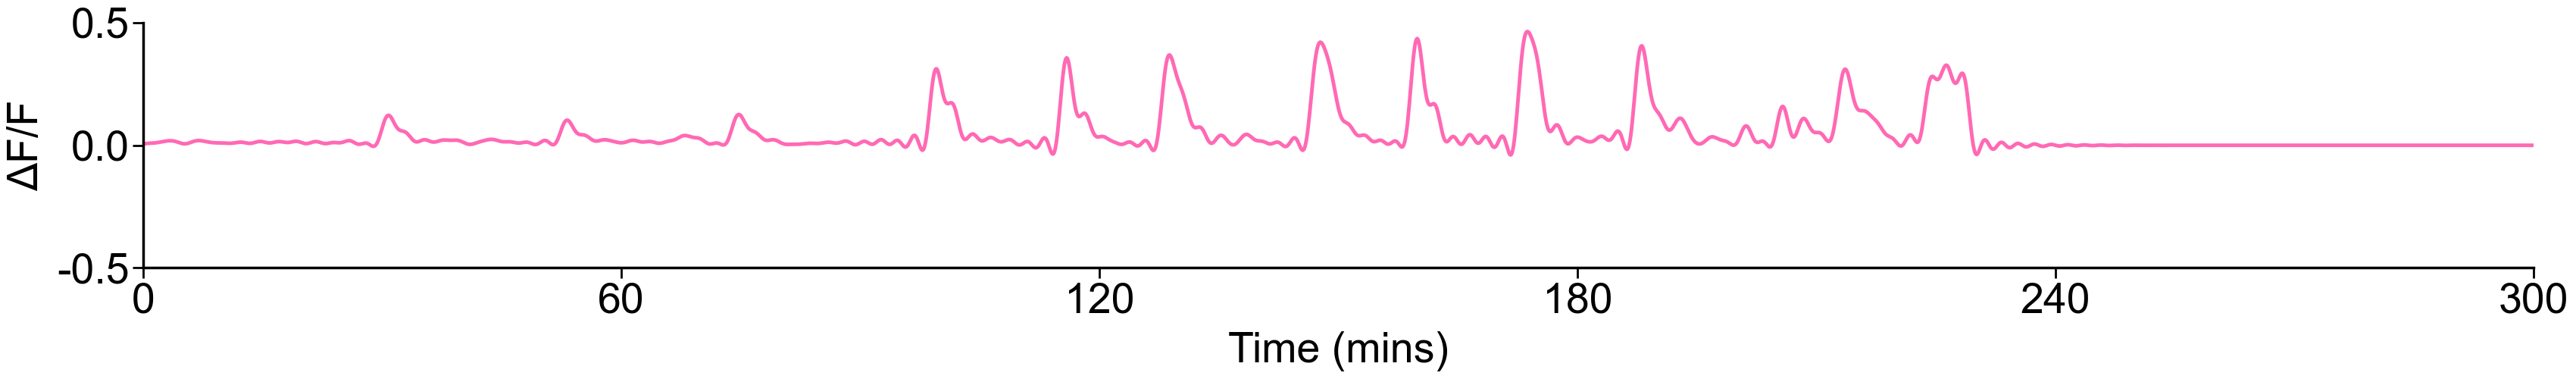

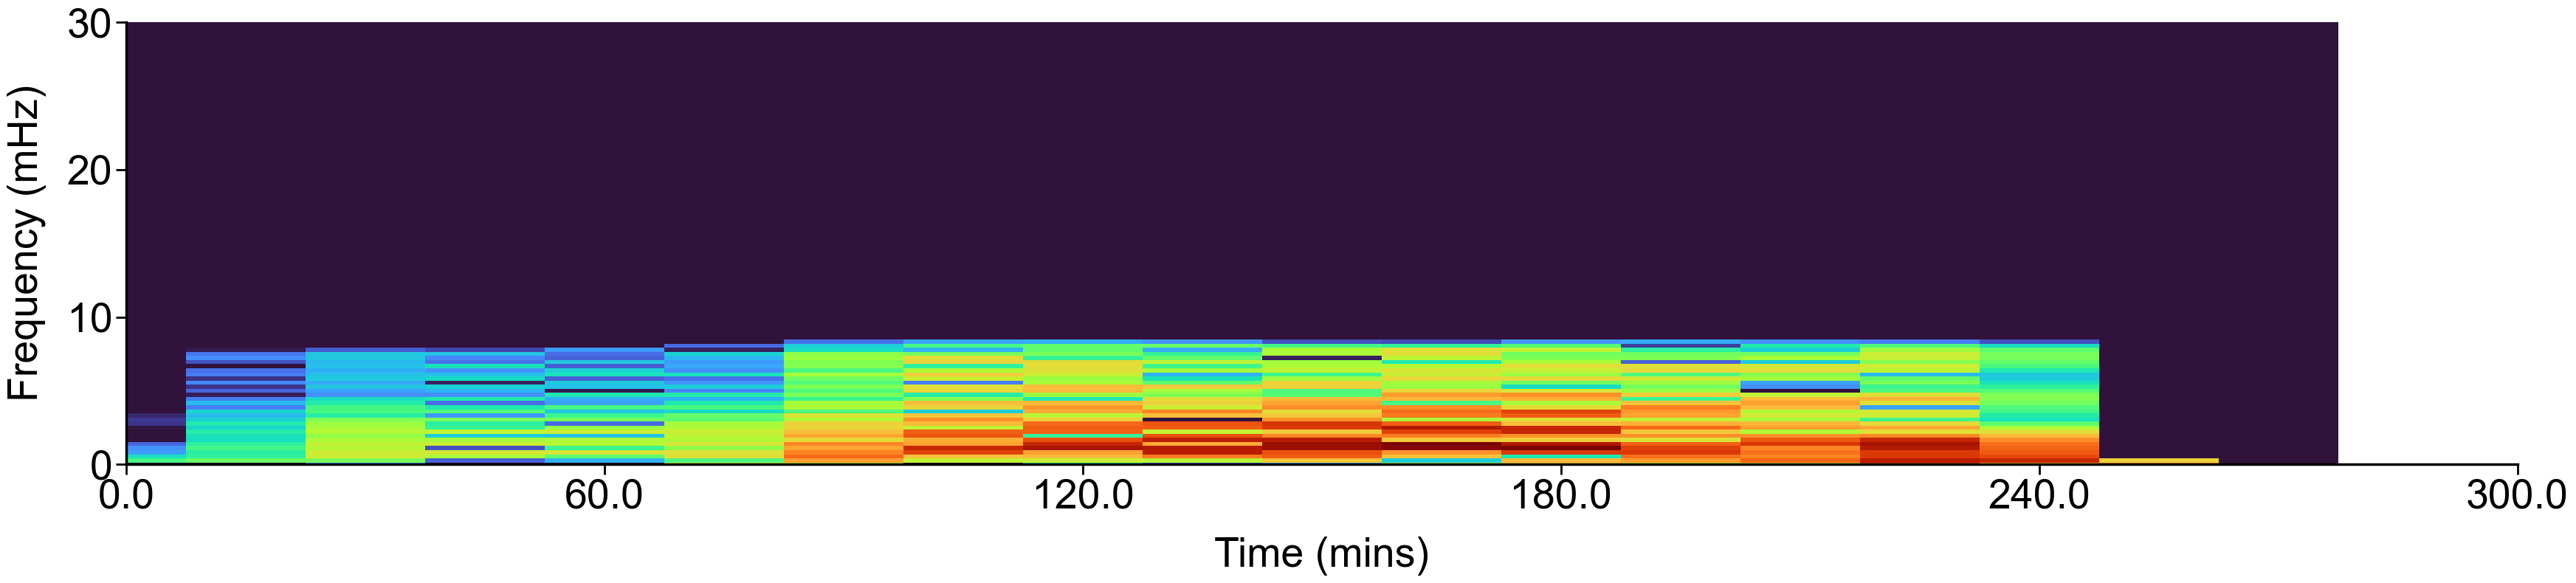

In [10]:
cutoff = 0.008  # frequency in Hz

f, t, Zxx = FrequencyAnalysis.calculate_STFT(dff)
lopass_dff = FrequencyAnalysis.apply_lopass_filter(dff, cutoff)

myplots.plot_trace(
    time,
    lopass_dff,
    trace_rc,
    color="hotpink",
    xmax=300,
    ymin=-0.5,
    ymax=0.5,
    yinterval=0.5,
)

new_f, new_t, new_Zxx = FrequencyAnalysis.calculate_STFT(lopass_dff)
myplots.plot_spec(
    new_f, new_t, new_Zxx, mymap, spec_rc, display_colorbar=False, xmax=300
)

## Scalogram

We use to [pywt](https://pywavelets.readthedocs.io/en/latest/ref/cwt.html) to perform the wavelet transfrom. Consider reading the documentation to gain an understanding the different parameters for this transform. 

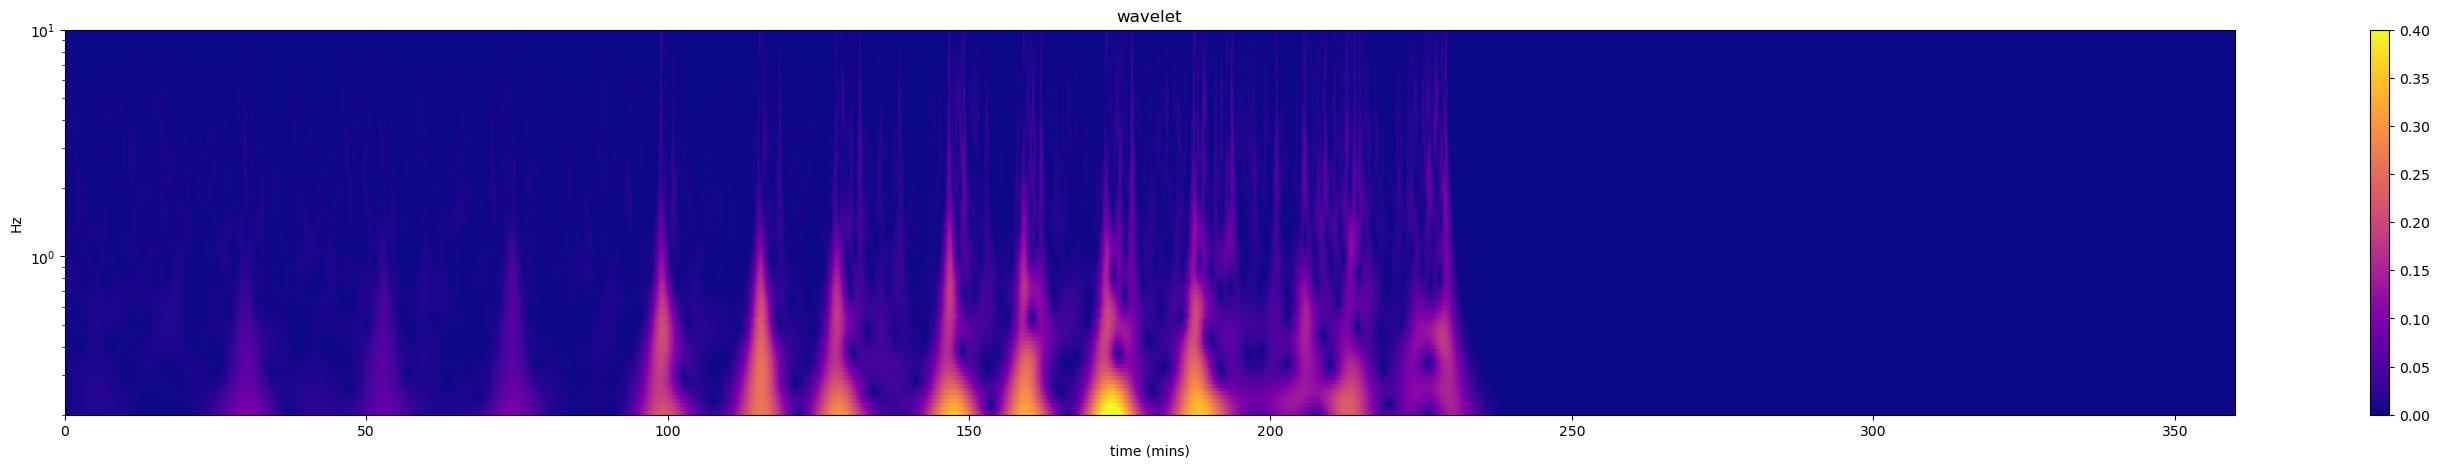

In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# calculate wavelets
wavelet = 'cmorl1-1'
widths = np.geomspace(start=1,stop=50, num=100) # logarithmic scales  (num is number of scales)
sampling_period = np.diff(time).mean()
cwtmatr, freqs = pywt.cwt(dff, widths, wavelet, sampling_period=sampling_period)
cwtmatr = np.abs(cwtmatr[:-1, :-1])

plt.figure(figsize=(35,5))
plt.title(f'wavelet')
scalogram = plt.pcolormesh(time, freqs, cwtmatr, cmap='plasma', vmin=0.0, vmax=0.4)
colorbar = plt.colorbar(scalogram)
plt.yscale('log')
plt.ylabel('Hz')
plt.xlabel('time (mins)')
plt.show()